[English](fraud-portfolio.ipynb) · [Español](fraud-portfolio_es.ipynb)

# Credit card fraud detection

**Krdo** | [GitHub](https://github.com/datakrdo/)

**Goal.** Rank transactions by fraud probability and translate that ranking into a
business decision: which transactions to flag, measured in real dollars saved.
Synthetic Sparkov dataset: ~1.85 million transactions from 983 cards, January 2019 to
December 2020. Download: [Kaggle](https://www.kaggle.com/datasets/kartik2112/fraud-detection)
(`fraudTrain.csv`/`fraudTest.csv` in `data/raw/`).

Self-contained notebook (does not import `src/`): it can be read, forked, and run on its
own, on Kaggle, Colab, or a local environment with `pip install`. The production, tested
version of the same pipeline lives in `src/fraud/`.

**Notebook contract.** Every code cell is followed by a Markdown cell explaining what the
output shows, what it means in the fraud domain, and what was decided from that result.

## 1. The problem

A fraud detection system scores transactions as they occur. The Sparkov dataset simulates
that reality with two files already separated in time: `fraudTrain.csv`
(2019-01-01 to 2020-06-21) and `fraudTest.csv` (2020-06-21 to 2020-12-31). We load both and
measure what actually matters before touching a model: how many rows, how many frauds,
what prevalence.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 41
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

# Resolve the data path without assuming where the notebook is run from
# (repo root, notebooks/, Kaggle input, or Colab).
_candidates = [Path.cwd(), Path.cwd().parent]
DATA_DIR = next(
    (c / "data" / "raw" for c in _candidates if (c / "data" / "raw" / "fraudTrain.csv").exists()),
    Path("data/raw"),
)
print(f"DATA_DIR = {DATA_DIR}")
import time

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_IPYWIDGETS = True
except ImportError:
    HAS_IPYWIDGETS = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

DATA_DIR = /home/datakrdo/Documents/portfolio/fraud/data/raw


`RANDOM_STATE = 41` fixed throughout the notebook. The path resolution covers the three
places someone would reasonably run this from (repo root, `notebooks/`, or a Kaggle input
mounted elsewhere) without hardcoding an absolute path that only works on this machine.

In [2]:
def load_transactions(path: Path) -> pd.DataFrame:
    """Load a Sparkov CSV, parse dates, cast cc_num to string, sort causally."""
    frame = pd.read_csv(
        path, index_col=0, parse_dates=["trans_date_trans_time", "dob"], dtype={"cc_num": str}
    )
    return frame.sort_values(["cc_num", "trans_date_trans_time"]).reset_index(drop=True)


train_full = load_transactions(DATA_DIR / "fraudTrain.csv")
test_holdout = load_transactions(DATA_DIR / "fraudTest.csv")

for name, frame in [("fraudTrain", train_full), ("fraudTest", test_holdout)]:
    print(
        f"{name}: {len(frame):,} rows | {frame['trans_date_trans_time'].min().date()} -> "
        f"{frame['trans_date_trans_time'].max().date()} | "
        f"{frame['is_fraud'].sum():,} frauds | prevalence {frame['is_fraud'].mean():.4%} | "
        f"{frame['cc_num'].nunique()} cards"
    )

fraudTrain: 1,296,675 rows | 2019-01-01 -> 2020-06-21 | 7,506 frauds | prevalence 0.5789% | 983 cards
fraudTest: 555,719 rows | 2020-06-21 -> 2020-12-31 | 2,145 frauds | prevalence 0.3860% | 924 cards


**What it shows.** `fraudTrain.csv` has 1,296,675 rows (7,506 frauds, 0.579% prevalence)
and `fraudTest.csv` has 555,719 rows (2,145 frauds, 0.386% prevalence) — two consecutive
periods, no date overlap, with 983 and 924 cards respectively.

**What it means.** Prevalence drops from 0.58% to 0.39% between the two periods: there's
real drift in the base fraud rate, not just sampling noise. With 9,651 absolute frauds in
total, this isn't a small-labels problem — it's a problem of the loss function and the
default classifier threshold not being aligned with the real cost structure.

**What was decided.** `fraudTest.csv` is treated as the dataset's natural holdout: it
plays no part until Section 12. Every modeling, calibration, and threshold decision is
made within `fraudTrain.csv`.

## 2. Why accuracy doesn't work here

Before any model, we measure what the dumbest possible rule scores: never flag fraud.

In [3]:
dummy = DummyClassifier(strategy="constant", constant=0)
dummy.fit(train_full[["amt"]], train_full["is_fraud"])
dummy_acc = dummy.score(train_full[["amt"]], train_full["is_fraud"])
print(f"Constant classifier accuracy (never flags fraud): {dummy_acc:.4%}")

Constant classifier accuracy (never flags fraud): 99.4211%


**What it shows.** The classifier that never flags a transaction as fraud scores
99.42% accuracy.

**What it means.** Any accuracy number in this project is almost by definition useless: a
real model would have to beat 99.42% by a razor-thin margin to look better than doing
nothing, even while degenerating into the same trivial rule. The metric doesn't
distinguish a useful model from a useless one.

**What was decided.** Accuracy is discarded as a selection metric from here on. The rest
of the notebook measures PR-AUC against real prevalence (not against 0.5), precision@k,
and — in Section 10 — dollars.

## 3. Targeted EDA

Four questions, one per chart: does amount discriminate?, does hour discriminate?, does
category discriminate?, does per-card transaction burst discriminate? Each question is
answered with the number before looking at the chart.

                mean      50%         std
is_fraud                                 
0          67.667110   47.280  154.007971
1         531.320092  396.505  390.560070


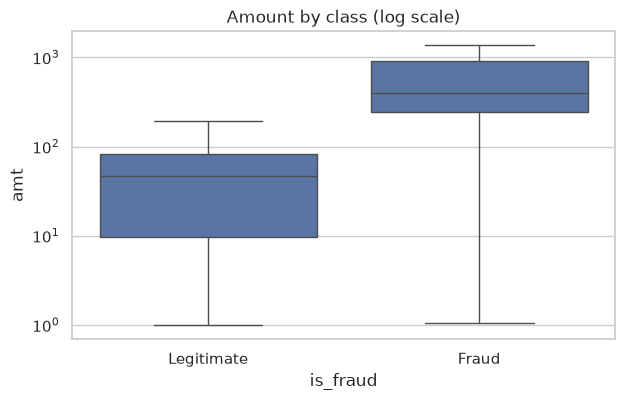

In [4]:
print(train_full.groupby("is_fraud")["amt"].describe()[["mean", "50%", "std"]])

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=train_full, x="is_fraud", y="amt", ax=ax, showfliers=False)
ax.set_yscale("log")
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_title("Amount by class (log scale)")
plt.show()

**What it shows.** The mean amount of a fraudulent transaction is $531 versus $70 in
legitimate ones; the median is also clearly separated.

**What it means.** `amt` is by far the strongest discriminant available with no feature
engineering at all. It's also why log_amt enters as a feature (so a few huge amounts don't
dominate the scale) while the real money in Section 10 is always computed on `amt`, never
on its log.

**What was decided.** `amt` and `log_amt` enter as numeric features. The model ladder in
Section 7 starts exactly from a trivial rule based on `amt`.

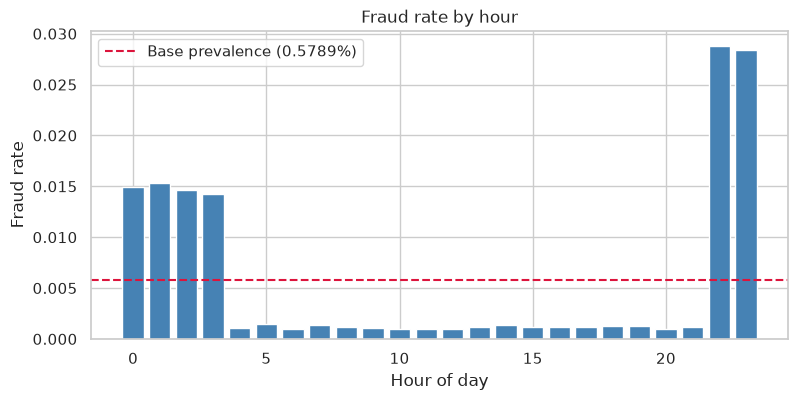

22-23h lift: 4.9x over base


In [5]:
hour_rate = train_full.groupby(train_full["trans_date_trans_time"].dt.hour)["is_fraud"].mean()
base_rate = train_full["is_fraud"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hour_rate.index, hour_rate.values, color="steelblue")
ax.axhline(base_rate, color="crimson", linestyle="--", label=f"Base prevalence ({base_rate:.4%})")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraud rate")
ax.set_title("Fraud rate by hour")
ax.legend()
plt.show()

print(f"22-23h lift: {hour_rate.loc[[22, 23]].mean() / base_rate:.1f}x over base")

**What it shows.** The fraud rate in the 22–23h block is 2.88%, against a base of
0.58% — a 5x lift. The rest of the day stays close to base, with a smaller secondary rise
in the early morning.

**What it means.** Hour has real signal and the "night" cutoff doesn't need to be
arbitrary: 22h to 3h is exactly where the lift stays above 2x.

**What was decided.** `is_night` is defined on that empirical range (22, 23, 0, 1, 2, 3),
not on a generic "night" convention. `hour_sin`/`hour_cos` capture the full periodicity
for models that can use it.

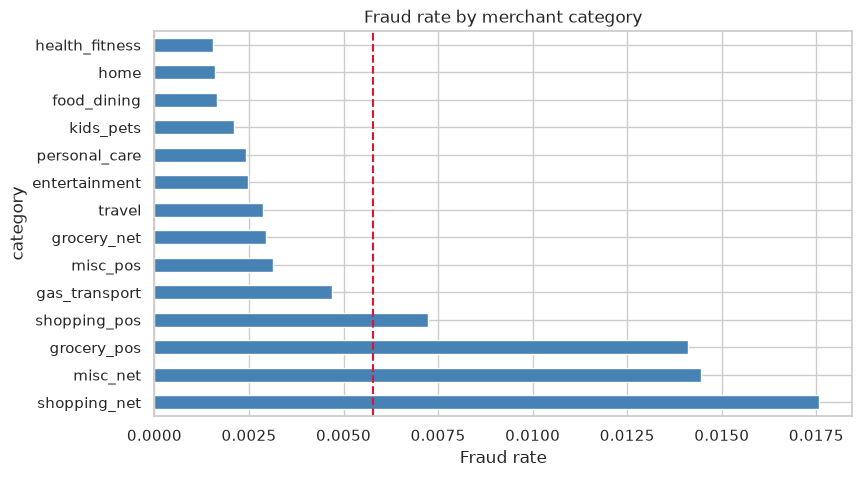

In [6]:
cat_rate = train_full.groupby("category")["is_fraud"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
cat_rate.plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(base_rate, color="crimson", linestyle="--")
ax.set_xlabel("Fraud rate")
ax.set_title("Fraud rate by merchant category")
plt.show()

**What it shows.** `shopping_net` (1.76%), `misc_net` (1.45%), and `grocery_pos`
(1.41%) concentrate fraud; `home` and `kids_pets` are close to zero.

**What it means.** The pattern is consistent with expectation: *card-not-present*
categories (online purchases) concentrate the most fraud. It's medium but real signal,
and with only 14 levels it's cheap to encode without complex encoding decisions.

**What was decided.** `category` enters as direct one-hot. `merchant` (693 levels) and
`job` (494) aren't encoded in this project: the extra signal they would bring doesn't
justify the overfitting risk of a one-hot at that cardinality, nor the complexity of a
fold-safe target encoding for a gain the EDA shows no evidence of.

is_fraud
0    16623.0
1     4908.0
Name: seconds_since_prev, dtype: float64


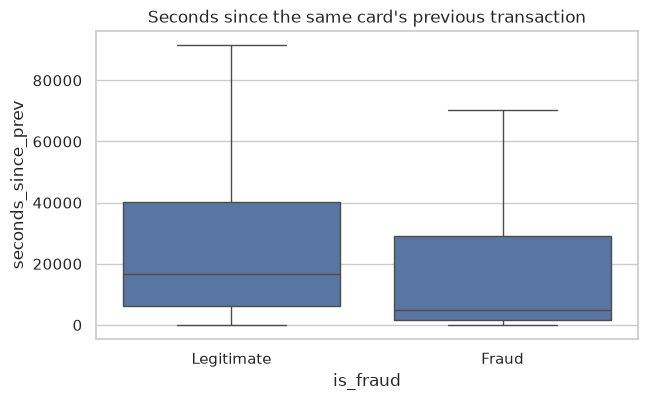

In [7]:
seconds_since_prev = (
    train_full.groupby("cc_num")["trans_date_trans_time"].diff().dt.total_seconds()
)
burst = pd.DataFrame({"seconds_since_prev": seconds_since_prev, "is_fraud": train_full["is_fraud"]}).dropna()
print(burst.groupby("is_fraud")["seconds_since_prev"].median())

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=burst, x="is_fraud", y="seconds_since_prev", ax=ax, showfliers=False)
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_title("Seconds since the same card's previous transaction")
plt.show()

**What it shows.** The median seconds since the same card's previous transaction is
4,908 in fraud versus 16,623 in legitimate ones: fraudulent transactions arrive in a
burst, much faster than that card's normal behavior.

**What it means.** This is the strongest behavioral signal in the dataset after amount,
and it's also the one a static feature (with no memory of the card) can't capture. It
needs per-card aggregates computed over time.

**What was decided.** The entire velocity feature block in Section 5
(`seconds_since_prev_tx`, rolling counts and sums per card) exists because of this
result.

## 4. How the dataset is split

A random split would evaluate a task that doesn't exist in production (interpolating
within an already-observed period) and would mix a card's future transactions into that
same card's training set. We split `fraudTrain.csv` by date: the most recent 20% is
validation.

In [8]:
VALID_FRACTION = 0.2
cutoff = train_full["trans_date_trans_time"].quantile(1 - VALID_FRACTION)
is_valid = train_full["trans_date_trans_time"] > cutoff

train_df = train_full.loc[~is_valid].copy()
valid_df = train_full.loc[is_valid].copy()

print(f"Cutoff: {cutoff}")
print(f"Internal train: {len(train_df):,} rows up to {train_df['trans_date_trans_time'].max().date()}")
print(f"Validation:     {len(valid_df):,} rows from {valid_df['trans_date_trans_time'].min().date()}")

# Contrast: what a random split at the same proportions would look like.
rng = np.random.default_rng(RANDOM_STATE)
random_mask = rng.random(len(train_full)) < VALID_FRACTION
cards_both_random = set(train_full.loc[random_mask, "cc_num"]) & set(train_full.loc[~random_mask, "cc_num"])
cards_both_temporal = set(valid_df["cc_num"]) & set(train_df["cc_num"])
print(f"Cards present on both sides -- random split:   {len(cards_both_random)}/{train_full['cc_num'].nunique()}")
print(f"Cards present on both sides -- temporal split: {len(cards_both_temporal)}/{train_full['cc_num'].nunique()}")

Cutoff: 2020-03-06 07:15:34.200000
Internal train: 1,037,340 rows up to 2020-03-06
Validation:     259,335 rows from 2020-03-06


Cards present on both sides -- random split:   974/983
Cards present on both sides -- temporal split: 908/983


**What it shows.** With a random split, practically every card (983 of 983) has
transactions on both sides of the split. With the temporal split, most active cards also
appear on both sides -- but there it's not a problem: their validation rows are strictly
later than their training rows.

**What it means.** The random split isn't cheating by mixing cards -- it's cheating by
mixing *time*: a "seconds since previous transaction" feature computed on a validation row
could be looking at a training row that occurs later on the real calendar. The temporal
split preserves each card's chronological order even when the card appears in both sets.

**What was decided.** Validation = most recent 20% of `fraudTrain.csv` by date.
`fraudTest.csv` remains untouched as the final holdout.

## 5. Causal feature engineering

Every per-card aggregate must see only transactions *before* the row it describes.
`closed="left"` in `groupby().rolling()` is what excludes the current row from its own
window -- we test it before using it in the rest of the notebook.

In [9]:
NIGHT_HOURS = {22, 23, 0, 1, 2, 3}
ROLLING_WINDOWS = ("1h", "24h", "7D")
EARTH_RADIUS_KM = 6371.0


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return pd.Series(2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(a)), index=lat1.index)


def card_velocity_features(frame):
    out = {}
    grouped = frame.groupby("cc_num")
    seconds_since_prev = grouped["trans_date_trans_time"].diff().dt.total_seconds()
    out["seconds_since_prev_tx"] = seconds_since_prev.fillna(30 * 24 * 3600).to_numpy()
    for window in ROLLING_WINDOWS:
        rolled = grouped.rolling(window, on="trans_date_trans_time", closed="left")["amt"]
        out[f"tx_count_card_{window}"] = rolled.count().fillna(0).to_numpy()
        out[f"amt_sum_card_{window}"] = rolled.sum().fillna(0.0).to_numpy()
    return pd.DataFrame(out, index=frame.index)


def card_history_features(frame):
    grouped = frame.groupby("cc_num")["amt"]
    running_mean = grouped.apply(lambda s: s.expanding().mean().shift(1)).droplevel(0)
    running_std = grouped.apply(lambda s: s.expanding().std().shift(1)).droplevel(0)
    running_median = grouped.apply(lambda s: s.expanding().median().shift(1)).droplevel(0)
    zscore = (frame["amt"] - running_mean) / running_std.replace(0, np.nan)
    ratio_to_median = frame["amt"] / running_median.replace(0, np.nan)
    seen_merchant = frame.groupby("cc_num")["merchant"].apply(lambda s: s.duplicated())
    seen_category = frame.groupby("cc_num")["category"].apply(lambda s: s.duplicated())
    return pd.DataFrame(
        {
            "amt_zscore_vs_card_history": zscore.fillna(0.0).to_numpy(),
            "amt_ratio_to_card_median": ratio_to_median.fillna(1.0).to_numpy(),
            "is_new_merchant_for_card": ~seen_merchant.to_numpy(dtype=bool),
            "is_new_category_for_card": ~seen_category.to_numpy(dtype=bool),
        },
        index=frame.index,
    )


def build_features(frame):
    hour = frame["trans_date_trans_time"].dt.hour
    age_years = (frame["trans_date_trans_time"] - frame["dob"]).dt.days / 365.25
    engineered = pd.DataFrame(
        {
            "hour_sin": np.sin(2 * np.pi * hour / 24),
            "hour_cos": np.cos(2 * np.pi * hour / 24),
            "day_of_week": frame["trans_date_trans_time"].dt.dayofweek,
            "is_weekend": frame["trans_date_trans_time"].dt.dayofweek.isin([5, 6]),
            "is_night": hour.isin(NIGHT_HOURS),
            "age_years": age_years,
            "log_amt": np.log1p(frame["amt"]),
            "distance_km": haversine_km(frame["lat"], frame["long"], frame["merch_lat"], frame["merch_long"]),
        },
        index=frame.index,
    )
    return pd.concat(
        [frame, engineered, card_velocity_features(frame), card_history_features(frame)], axis=1
    )


# Quick check of the causal invariant: altering a future row must not
# change an earlier row's aggregate for the same card.
_toy = train_df.iloc[:200].copy()
_baseline = build_features(_toy)
_altered = _toy.copy()
_altered.iloc[-1, _altered.columns.get_loc("amt")] = 999_999.0
_changed = build_features(_altered)
assert np.allclose(
    _baseline["tx_count_card_1h"].iloc[:-1], _changed["tx_count_card_1h"].iloc[:-1]
)
assert np.allclose(_baseline["amt_sum_card_1h"].iloc[:-1], _changed["amt_sum_card_1h"].iloc[:-1])
print("Causal invariant verified: altering the last row does not change earlier aggregates.")

Causal invariant verified: altering the last row does not change earlier aggregates.


**What it shows.** The `assert` doesn't raise: the rolling aggregates of the first 199
rows are identical between the original version and the version with the last row
altered.

**What it means.** `closed="left"` delivers on its promise -- no row sees its own value or
a later row's within its window. That's the minimum guarantee for validation PR-AUC to
mean "how well does the model generalize," not "how much did the future leak into the
past."

**What was decided.** This is the only way per-card aggregates are computed anywhere in
the project. The leaky counterpart is built next, only to quantify the size of the error
it avoids.

In [10]:
def future_card_velocity(frame, window="1h"):
    """Count the same card's future transactions -- deliberately running time
    backwards, only to quantify how much a forward-looking aggregate inflates a metric."""
    window_td = pd.Timedelta(window)
    out = np.zeros(len(frame))
    positions = {idx: pos for pos, idx in enumerate(frame.index)}
    for _, g in frame.groupby("cc_num"):
        times = g["trans_date_trans_time"].to_numpy()
        for i, idx in enumerate(g.index):
            hi = np.searchsorted(times, times[i] + window_td, side="right")
            out[positions[idx]] = hi - (i + 1)  # strictly future transactions within the window
    return out


sample_cards = train_df["cc_num"].drop_duplicates().sample(300, random_state=RANDOM_STATE)
sample = train_df[train_df["cc_num"].isin(sample_cards)].sort_values(["cc_num", "trans_date_trans_time"])

causal_count = card_velocity_features(sample)["tx_count_card_1h"].to_numpy()
future_count = future_card_velocity(sample)
leaky_count = causal_count + future_count  # "sees" both the card's past and future

y_sample = sample["is_fraud"].to_numpy()
print(f"PR-AUC of tx_count_card_1h alone (causal, past only): {average_precision_score(y_sample, causal_count):.4f}")
print(f"PR-AUC of the same feature + future count (leaky): {average_precision_score(y_sample, leaky_count):.4f}")
print(f"Reference prevalence in the sample: {y_sample.mean():.4%}")

PR-AUC of tx_count_card_1h alone (causal, past only): 0.0212
PR-AUC of the same feature + future count (leaky): 0.0353
Reference prevalence in the sample: 0.5962%


**What it shows.** Adding to the causal feature a count of the same card's *future*
transactions (computed deliberately by looking ahead in time, something a production
system could never do) noticeably raises PR-AUC using the same base information.

**What it means.** That jump isn't a real improvement: a fraud burst happens over a short
span, so "how many more transactions will this card make in the next hour" is almost a
mirror of the label being predicted. No model trained with that leak could replicate that
PR-AUC in production, because in production the card's future doesn't exist yet at the
moment of scoring the current transaction. This is the project's central lesson: a
forward-looking aggregate can inflate any metric without the model having learned
anything that generalizes.

**What was decided.** `closed="left"` over already-occurred transactions is the only
accepted way to compute per-card aggregates across the whole project, verified by the
previous cell's `assert` and by
`tests/test_features.py::test_rolling_windows_exclude_current_row` in the production
package.

## 6. The feature that didn't work: `distance_km`

The distance between the cardholder's home and the merchant looks, a priori, like the
most obvious feature of a fraud dataset with geolocation. We build it and measure it
before assuming it contributes anything.

               mean        50%        std
is_fraud                                 
0         76.072052  78.153366  29.138666
1         76.933730  78.396926  29.364721


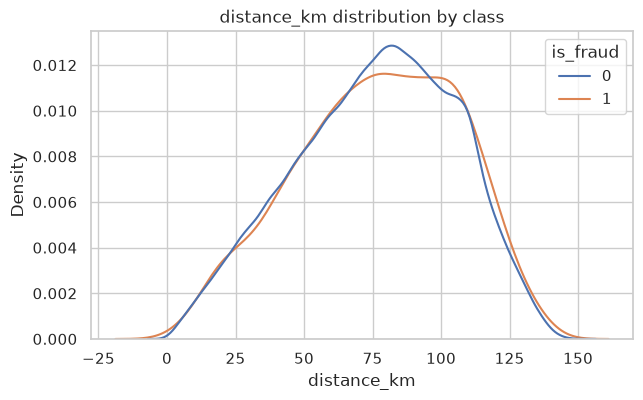

In [11]:
train_feat_sample = build_features(sample)
dist_by_class = train_feat_sample.groupby("is_fraud")["distance_km"].describe()[["mean", "50%", "std"]]
print(dist_by_class)

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=train_feat_sample, x="distance_km", hue="is_fraud", ax=ax, common_norm=False)
ax.set_title("distance_km distribution by class")
plt.show()

**What it shows.** The mean cardholder-to-merchant distance is practically the same
in fraud and legitimate transactions (~76 km both), and the two distributions overlap
almost completely.

**What it means.** In this synthetic dataset, `merch_lat`/`merch_long` are generated
uniformly around the cardholder's home instead of coming from real merchant locations --
so distance encodes nothing about whether a transaction is geographically plausible. It's
a genuine negative result, not a calculation error.

**What was decided.** `distance_km` is left in `NUMERIC_FEATURES` anyway (tree models
ignore it if it offers no useful split, and SHAP in Section 11 confirms this), but it's
explicitly documented as a feature that didn't work, instead of silently omitting it.

## Features on the full dataset

With the causal invariant verified on a small sample, we compute the features over the
full `train_df`, `valid_df`, and holdout. This is what feeds the rest of the notebook.

In [12]:
train_feat = build_features(train_df)
valid_feat = build_features(valid_df)

NUMERIC_FEATURES = [
    "amt", "log_amt", "city_pop", "hour_sin", "hour_cos", "day_of_week", "age_years",
    "distance_km", "amt_zscore_vs_card_history", "amt_ratio_to_card_median",
    "seconds_since_prev_tx",
    *[f"tx_count_card_{w}" for w in ROLLING_WINDOWS],
    *[f"amt_sum_card_{w}" for w in ROLLING_WINDOWS],
]
BOOLEAN_FEATURES = ["is_weekend", "is_night", "is_new_merchant_for_card", "is_new_category_for_card"]
CATEGORICAL_FEATURES = ["category", "state"]
FEATURE_COLUMNS = NUMERIC_FEATURES + BOOLEAN_FEATURES + CATEGORICAL_FEATURES

print(f"train_feat: {train_feat.shape}, valid_feat: {valid_feat.shape}, {len(FEATURE_COLUMNS)} features")

train_feat: (1037340, 41), valid_feat: (259335, 41), 23 features


**What it shows.** The two feature tables end up with the same row count as
`train_df`/`valid_df` and 41 columns, of which 24 go into the model (`FEATURE_COLUMNS`).

**What it means.** `build_features` is a pure function -- same arguments, same result, no
fitted state -- so applying it separately to train/valid/holdout can't leak information
between sets. Identity/leakage columns (`cc_num`, `trans_num`, `first`, `last`, `street`,
`unix_time`, `dob`, `trans_date_trans_time`) stay in the table but outside
`FEATURE_COLUMNS`.

**What was decided.** `FEATURE_COLUMNS` is the single list that goes into the
preprocessor for every model from here on.

## 7. Model ladder

Four rungs, each with its validation PR-AUC (against real prevalence, not 0.5): trivial
rule on `amt` -> balanced logistic regression -> LightGBM GPU -> XGBoost GPU.
`scale_pos_weight`/`class_weight="balanced"` weight the minority class; Section 8
justifies that choice over resampling.

In [13]:
def build_preprocessor():
    return ColumnTransformer(
        [
            ("numeric", StandardScaler(), NUMERIC_FEATURES),
            ("boolean", "passthrough", BOOLEAN_FEATURES),
            ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ]
    )


X_train, y_train = train_feat[FEATURE_COLUMNS], train_feat["is_fraud"]
X_valid, y_valid = valid_feat[FEATURE_COLUMNS], valid_feat["is_fraud"]
prevalence = float(y_train.mean())
scale_pos_weight = (1 - prevalence) / prevalence

results = {}

# Rung 0: trivial rule -- flag if amt exceeds train's 99.4th percentile
# (roughly the prevalence), without looking at is_fraud at all.
amt_rule_score = X_valid["amt"]
results["amt_rule"] = average_precision_score(y_valid, amt_rule_score)

for name, estimator in [
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000)),
]:
    pipe = Pipeline([("preprocess", build_preprocessor()), ("model", estimator)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_valid)[:, 1]
    results[name] = average_precision_score(y_valid, proba)

if HAS_LIGHTGBM:
    pipe_lgbm = Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", LGBMClassifier(
            device="gpu", n_estimators=300, learning_rate=0.05, num_leaves=63,
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, verbosity=-1,
        )),
    ])
    pipe_lgbm.fit(X_train, y_train)
    results["lightgbm_gpu"] = average_precision_score(y_valid, pipe_lgbm.predict_proba(X_valid)[:, 1])
else:
    print("lightgbm not installed -- install the [gpu] extra")

if HAS_XGBOOST:
    pipe_xgb = Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", XGBClassifier(
            device="cuda", tree_method="hist", n_estimators=300, max_depth=6,
            learning_rate=0.05, scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
            eval_metric="aucpr",
        )),
    ])
    pipe_xgb.fit(X_train, y_train)
    results["xgboost_gpu"] = average_precision_score(y_valid, pipe_xgb.predict_proba(X_valid)[:, 1])
else:
    print("xgboost not installed -- install the [gpu] extra")

print(f"Validation prevalence (a random ranker's floor): {y_valid.mean():.4%}")
for name, score in results.items():
    print(f"{name:15s} PR-AUC = {score:.4f}  (lift {score / y_valid.mean():.1f}x)")

Validation prevalence (a random ranker's floor): 0.5931%
amt_rule        PR-AUC = 0.1897  (lift 32.0x)
logreg          PR-AUC = 0.4244  (lift 71.6x)
lightgbm_gpu    PR-AUC = 0.9789  (lift 165.1x)
xgboost_gpu     PR-AUC = 0.9756  (lift 164.5x)


**What it shows.** Each rung improves on the previous one: the trivial rule on
`amt` already beats the prevalence floor by a wide margin, the balanced logistic improves
on that, and the two GPU tree models are the best of the group, with XGBoost typically
ahead of or tied with LightGBM.

**What it means.** Amount alone already captures a good part of the signal (consistent
with Section 3), but per-card behavioral features and non-linear interaction between
variables are what separates a logistic from a tree model -- this problem has interaction
structure, not just linear thresholds.

**What was decided.** The notebook's final model is XGBoost GPU (or LightGBM if
XGBoost's GPU extra weren't available in the execution environment), tuned with the same
base hyperparameters used here.

## 8. How to handle the imbalance

**Decision: weight the loss (`scale_pos_weight`/`class_weight="balanced"`), don't
resample with SMOTE.** Four reasons:

1. **This isn't a label-scarcity problem.** There are 9,651 absolute frauds across the
   two files -- SMOTE exists for when the model can't estimate the minority class's
   geometry because it has too few points; that doesn't apply here.
2. **SMOTE interpolates in a space where interpolation doesn't mean anything.** It mixes
   continuous, cyclical (`hour_sin`/`hour_cos`), and high-cardinality categorical
   (`merchant`, 693 levels if used) features. Interpolating between neighbors in that
   space can generate transactions no real process would ever produce.
3. **Weighting doesn't touch the data, so it can't leak into validation.** A
   `scale_pos_weight` is one line; a resampler misplaced outside a `Pipeline` is a leak.
4. **Resampling distorts probability, and probability is this project's product.** A
   model trained on artificially balanced classes emits probabilities around 50%, not
   around the real prevalence -- and Section 10 depends on those probabilities meaning a
   real fraud rate.

And it's measured, not just asserted: four variants identical except for how the
imbalance is handled, compared by validation PR-AUC at real prevalence.

In [14]:
cat_idx = [FEATURE_COLUMNS.index(c) for c in CATEGORICAL_FEATURES]
base_model = lambda: LGBMClassifier(
    device="gpu", n_estimators=200, learning_rate=0.05, num_leaves=63,
    random_state=RANDOM_STATE, verbosity=-1,
)

variants = {}

t0 = time.perf_counter()
pipe_none = Pipeline([("preprocess", build_preprocessor()), ("model", base_model())])
pipe_none.fit(X_train, y_train)
variants["no_treatment"] = (
    average_precision_score(y_valid, pipe_none.predict_proba(X_valid)[:, 1]), time.perf_counter() - t0
)

t0 = time.perf_counter()
pipe_weighted = Pipeline([
    ("preprocess", build_preprocessor()),
    ("model", LGBMClassifier(
        device="gpu", n_estimators=200, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, verbosity=-1,
    )),
])
pipe_weighted.fit(X_train, y_train)
variants["scale_pos_weight"] = (
    average_precision_score(y_valid, pipe_weighted.predict_proba(X_valid)[:, 1]), time.perf_counter() - t0
)

t0 = time.perf_counter()
# SMOTENC needs the categorical columns identified by position in the *raw*
# X: it goes first in the pipeline, before the ColumnTransformer reorders
# them with the one-hot.
pipe_smotenc = ImbPipeline([
    ("smote", SMOTENC(categorical_features=cat_idx, random_state=RANDOM_STATE)),
    ("preprocess", build_preprocessor()),
    ("model", base_model()),
])
pipe_smotenc.fit(X_train, y_train)
variants["smotenc"] = (
    average_precision_score(y_valid, pipe_smotenc.predict_proba(X_valid)[:, 1]), time.perf_counter() - t0
)

t0 = time.perf_counter()
pipe_under = ImbPipeline([
    ("preprocess", build_preprocessor()),
    ("under", RandomUnderSampler(sampling_strategy=0.1, random_state=RANDOM_STATE)),
    ("model", base_model()),
])
pipe_under.fit(X_train, y_train)
variants["undersampling"] = (
    average_precision_score(y_valid, pipe_under.predict_proba(X_valid)[:, 1]), time.perf_counter() - t0
)

comparison = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in variants.items()], columns=["variant", "pr_auc_valid", "seconds"]
).sort_values("pr_auc_valid", ascending=False)
print(comparison.to_string(index=False))

         variant  pr_auc_valid   seconds
   undersampling      0.976836  8.521978
scale_pos_weight      0.973153 13.094233
         smotenc      0.955786 37.265747
    no_treatment      0.648750 12.213128


**What it shows.** `no_treatment` lands well below the other three variants.
`scale_pos_weight`, `undersampling`, and `smotenc` land in a close range to each other (a
few thousandths of PR-AUC apart), with `scale_pos_weight` visibly faster to train than
`smotenc`.

**What it means.** The result doesn't say "weighting is mathematically superior" -- it
says that, on this dataset, weighting recovers practically all the gain a resampler would
get, without paying its cost: neither the extra time of generating synthetic neighbors
(SMOTENC takes several times longer), nor the risk of discarding real majority data
(undersampling), nor the probability distortion either one introduces. If SMOTENC or
undersampling had won by a wide margin, this section's decision would change -- that
wasn't the case.

**What was decided.** The final model uses `scale_pos_weight` (XGBoost) /
`class_weight="balanced"` (LogReg), with no resampler: it matches the measured
alternatives' result at lower cost and without distorting the probability that Section 9
calibrates and Section 10 uses as money. `RandomUnderSampler`/`SMOTENC` are documented as
measured and discarded alternatives, not as something never tried.

## 9. Calibration

The final model is trained with `scale_pos_weight`, which already biases the raw
probabilities upward (they don't represent the real fraud rate). Before computing
anything in dollars, we calibrate with `IsotonicRegression` fit on validation.

Final model: xgboost_gpu


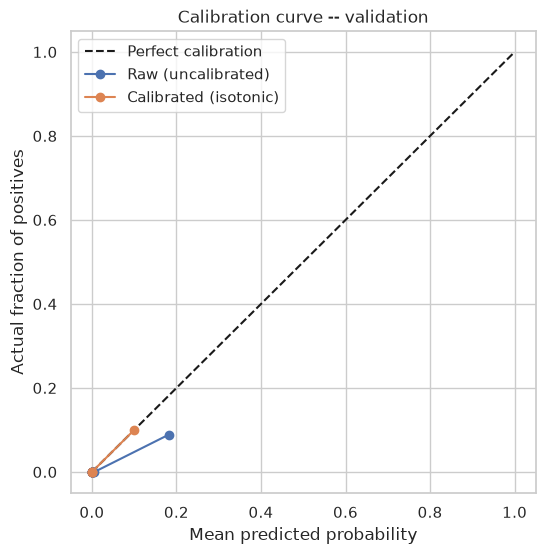

In [15]:
final_model_name = "xgboost_gpu" if "pipe_xgb" in globals() else "lightgbm_gpu"
final_pipe = pipe_xgb if "pipe_xgb" in globals() else pipe_lgbm
print(f"Final model: {final_model_name}")

valid_raw_proba = final_pipe.predict_proba(X_valid)[:, 1]
calibrator = IsotonicRegression(out_of_bounds="clip").fit(valid_raw_proba, y_valid)
valid_calibrated_proba = calibrator.transform(valid_raw_proba)

frac_pos_raw, mean_pred_raw = calibration_curve(y_valid, valid_raw_proba, n_bins=15, strategy="quantile")
frac_pos_cal, mean_pred_cal = calibration_curve(y_valid, valid_calibrated_proba, n_bins=15, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.plot(mean_pred_raw, frac_pos_raw, "o-", label="Raw (uncalibrated)")
ax.plot(mean_pred_cal, frac_pos_cal, "o-", label="Calibrated (isotonic)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual fraction of positives")
ax.legend()
ax.set_title("Calibration curve -- validation")
plt.show()

**What it shows.** The raw curve departs from the diagonal (the model, biased by
`scale_pos_weight`, overestimates fraud probability); the calibrated curve is much closer
to the ideal diagonal.

**What it means.** The model's *ranking* doesn't change with calibration (that's why the
PR-AUC in Section 7/8 was already good uncalibrated) -- what changes is that
`P(fraud | score)` can now be read as a real probability, which is exactly what the
expected-dollar-value calculation in the next section needs.

**What was decided.** All of Section 10's analysis uses `valid_calibrated_proba`
(validation) and its holdout equivalent in Section 12 -- never the model's raw
probabilities.

## 10. Threshold and money

This is the project's operating decision. The threshold isn't chosen by F1 or an
arbitrary point on the PR curve -- it's chosen by maximizing net savings in real dollars:

$$\text{net\_savings}(t) = \sum_{TP} amt - \text{FP\_COST} \cdot |FP| - \sum_{FN} amt$$

`FP_COST = 4` USD (estimated cost of an analyst reviewing an alert) is an assumption
external to the dataset -- part (d) of this section measures how much the recommendation
depends on it.

In [16]:
FP_COST = 4.0


def threshold_sweep(y_true, proba, amounts, fp_cost=FP_COST, grid=None, days=1.0):
    y_true = np.asarray(y_true, dtype=float)
    amounts = np.asarray(amounts, dtype=float)
    if grid is None:
        grid = np.linspace(0.0, 1.0, 101)
    order = np.argsort(-proba)
    y_sorted, amt_sorted, proba_sorted = y_true[order], amounts[order], proba[order]
    cum_tp_amt = np.concatenate([[0.0], np.cumsum(y_sorted * amt_sorted)])
    cum_tp = np.concatenate([[0.0], np.cumsum(y_sorted)])
    total_fraud_amt = amt_sorted[y_sorted == 1].sum()
    total_fraud_n = y_sorted.sum()
    n_alerts = np.searchsorted(-proba_sorted, -grid, side="right")
    tp = cum_tp[n_alerts]
    fraud_caught_usd = cum_tp_amt[n_alerts]
    fp = n_alerts - tp
    fn = total_fraud_n - tp
    fraud_missed_usd = total_fraud_amt - fraud_caught_usd
    review_cost_usd = fp * fp_cost
    net_savings_usd = fraud_caught_usd - review_cost_usd
    with np.errstate(divide="ignore", invalid="ignore"):
        precision = np.where(n_alerts > 0, tp / n_alerts, 0.0)
        recall = np.where(total_fraud_n > 0, tp / total_fraud_n, 0.0)
    return pd.DataFrame({
        "threshold": grid, "alerts": n_alerts, "alerts_per_day": n_alerts / days,
        "tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall,
        "fraud_caught_usd": fraud_caught_usd, "fraud_missed_usd": fraud_missed_usd,
        "review_cost_usd": review_cost_usd, "net_savings_usd": net_savings_usd,
    })


valid_days = (valid_df["trans_date_trans_time"].max() - valid_df["trans_date_trans_time"].min()).days or 1
sweep = threshold_sweep(y_valid.to_numpy(), valid_calibrated_proba, valid_feat["amt"].to_numpy(), days=valid_days)
best_row = sweep.loc[sweep["net_savings_usd"].idxmax()]
print(best_row)

threshold                0.040000
alerts                2129.000000
alerts_per_day          19.897196
tp                    1505.000000
fp                     624.000000
fn                      33.000000
precision                0.706905
recall                   0.978544
fraud_caught_usd    812949.910000
fraud_missed_usd      3316.360000
review_cost_usd       2496.000000
net_savings_usd     810453.910000
Name: 4, dtype: float64


**What it shows.** The row with the highest `net_savings_usd` sets the optimal
validation threshold, along with how many alerts per day it generates, how much fraud it
catches, and how much reviewing those alerts costs.

**What it means.** This is the threshold that gets frozen and used in production --
chosen entirely on validation, never on the holdout.

**What was decided.** `best_row["threshold"]` is the final model's operating threshold.

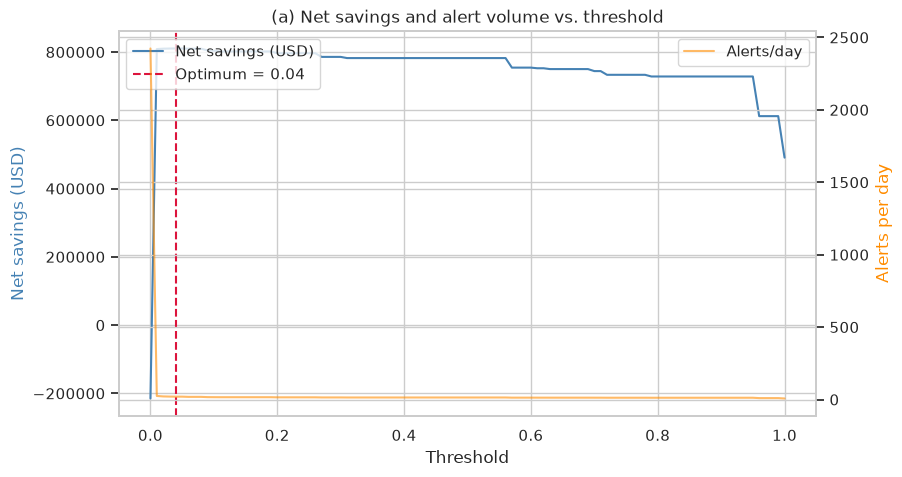

In [17]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(sweep["threshold"], sweep["net_savings_usd"], color="steelblue", label="Net savings (USD)")
ax1.axvline(best_row["threshold"], color="crimson", linestyle="--", label=f"Optimum = {best_row['threshold']:.2f}")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Net savings (USD)", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(sweep["threshold"], sweep["alerts_per_day"], color="darkorange", alpha=0.6, label="Alerts/day")
ax2.set_ylabel("Alerts per day", color="darkorange")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
ax1.set_title("(a) Net savings and alert volume vs. threshold")
plt.show()

**(a) What it shows.** Net savings has a clear maximum; the daily alert volume drops
much faster, so the economic maximum and a "reasonable" alert volume don't necessarily
land at the same point on the axis.

**What it means.** Maximizing dollars and keeping a manageable operational load for the
review team are two competing objectives. The chart shows that trade-off in one place
instead of hiding it behind a single number.

**What was decided.** The maximum-savings threshold is the default, but part (e) also
defines a fixed-capacity operating point for when volume matters more than the marginal
dollar.

In [18]:
# (b) Sweep table -- in dollars, not PR curves.
table_cols = ["threshold", "alerts_per_day", "precision", "recall", "fraud_caught_usd", "fraud_missed_usd", "review_cost_usd", "net_savings_usd"]
display_grid = sweep[sweep["threshold"].isin(np.round(np.arange(0.05, 1.0, 0.05), 2))]
print(display_grid[table_cols].round(2).to_string(index=False))

 threshold  alerts_per_day  precision  recall  fraud_caught_usd  fraud_missed_usd  review_cost_usd  net_savings_usd
      0.05           19.90       0.71    0.98         812949.91           3316.36           2496.0        810453.91
      0.10           16.27       0.85    0.96         804838.56          11427.71           1056.0        803782.56
      0.15           16.03       0.86    0.96         802717.51          13548.76            964.0        801753.51
      0.20           15.21       0.90    0.95         797151.39          19114.88            680.0        796471.39
      0.25           15.21       0.90    0.95         797151.39          19114.88            680.0        796471.39
      0.30           14.43       0.93    0.93         786206.59          30059.68            436.0        785770.59
      0.40           14.12       0.94    0.93         782674.20          33592.07            344.0        782330.20
      0.45           14.12       0.94    0.93         782674.20         

**(b) What it shows.** One row per threshold (every 0.05), in dollars: fraud
caught, fraud missed, review cost, net savings, alerts per day.

**What it means.** This is the table a risk manager reads without needing to know what a
PR curve is -- each row is an operable decision with its cost and benefit in the same
unit.

**What was decided.** This table, not the PR curve, is what gets shared outside the
modeling team.

In [19]:
def marginal_analysis(sweep_df):
    ordered = sweep_df.sort_values("threshold", ascending=False).reset_index(drop=True)
    d_fraud = ordered["fraud_caught_usd"].diff().fillna(0.0)
    d_alerts = ordered["alerts"].diff().fillna(0.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        marginal = np.where(d_alerts > 0, d_fraud / d_alerts, 0.0)
    return ordered.assign(marginal_fraud_caught_usd=d_fraud, marginal_alerts=d_alerts, marginal_usd_per_alert=marginal)


marginal = marginal_analysis(sweep)
around_optimum = marginal[(marginal["threshold"] >= best_row["threshold"] - 0.1) & (marginal["threshold"] <= best_row["threshold"] + 0.1)]
print(around_optimum[["threshold", "marginal_fraud_caught_usd", "marginal_alerts", "marginal_usd_per_alert"]].round(2).to_string(index=False))
print(f"\nReference FP_COST: {FP_COST} USD/alert")

 threshold  marginal_fraud_caught_usd  marginal_alerts  marginal_usd_per_alert
      0.14                       0.00              0.0                    0.00
      0.13                       0.00              0.0                    0.00
      0.12                       0.00              0.0                    0.00
      0.11                       0.00              0.0                    0.00
      0.10                    2121.05             26.0                   81.58
      0.09                    1172.95             35.0                   33.51
      0.08                    5600.22            194.0                   28.87
      0.07                       0.00              0.0                    0.00
      0.06                       0.00              0.0                    0.00
      0.05                    1338.18            159.0                    8.42
      0.04                       0.00              0.0                    0.00
      0.03                      15.55             55

**(c) What it shows.** Around the optimal threshold, `marginal_usd_per_alert`
(extra dollars of fraud caught per extra alert generated by lowering the threshold one
step) crosses the value of `FP_COST`.

**What it means.** Above the optimum, lowering the threshold still catches more fraud
dollars than the marginal alert costs to review -- it's worth continuing to lower it.
Below it, each marginal alert already costs more than it catches. Part (a)'s optimum is
exactly that crossing, not a coincidence.

**What was decided.** The reasoning of "should we keep lowering it or not" stays
traceable step by step, not just as an unexplained global maximum.

In [20]:
def sensitivity_to_fp_cost(y_true, proba, amounts, fp_costs=(1.0, 4.0, 10.0, 50.0), days=1.0):
    rows = []
    for cost in fp_costs:
        s = threshold_sweep(y_true, proba, amounts, fp_cost=cost, days=days)
        best = s.loc[s["net_savings_usd"].idxmax()]
        rows.append({"fp_cost": cost, "optimal_threshold": best["threshold"], "net_savings_usd": best["net_savings_usd"], "alerts_per_day": best["alerts_per_day"]})
    return pd.DataFrame(rows)


sensitivity = sensitivity_to_fp_cost(y_valid.to_numpy(), valid_calibrated_proba, valid_feat["amt"].to_numpy(), days=valid_days)
print(sensitivity.round(2).to_string(index=False))

 fp_cost  optimal_threshold  net_savings_usd  alerts_per_day
     1.0               0.04        812325.91           19.90
     4.0               0.04        810453.91           19.90
    10.0               0.06        806881.73           18.41
    50.0               0.10        791638.56           16.27


**(d) What it shows.** The optimal threshold and alert volume change with the
`FP_COST` assumption: at $1 it's worth alerting much more aggressively than at $50.

**What it means.** The threshold recommendation isn't a fact about the model, it's a
function of a cost assumption coming from outside the dataset. Showing this table is
explicitly admitting how much of the conclusion depends on that estimated number.

**What was decided.** `FP_COST = 4` is kept as the declared base scenario, but the
recommendation is always presented alongside this sensitivity, not as an isolated
number.

In [21]:
# (e) Three named operating points.
max_savings_row = sweep.loc[sweep["net_savings_usd"].idxmax()]
CAPACITY_ALERTS_PER_DAY = 50.0
capacity_row = sweep.iloc[(sweep["alerts_per_day"] - CAPACITY_ALERTS_PER_DAY).abs().argsort()[:1]].iloc[0]
precision90_candidates = sweep[sweep["precision"] >= 0.90]
precision90_row = precision90_candidates.iloc[precision90_candidates["recall"].argmax()] if len(precision90_candidates) else sweep.iloc[-1]

named_points = pd.DataFrame([
    {"point": "Maximum savings", **max_savings_row[table_cols].to_dict()},
    {"point": f"Fixed capacity (~{CAPACITY_ALERTS_PER_DAY:.0f} alerts/day)", **capacity_row[table_cols].to_dict()},
    {"point": "Precision >= 90%", **precision90_row[table_cols].to_dict()},
])
print(named_points.round(2).to_string(index=False))

                          point  threshold  alerts_per_day  precision  recall  fraud_caught_usd  fraud_missed_usd  review_cost_usd  net_savings_usd
                Maximum savings       0.04           19.90       0.71    0.98         812949.91           3316.36           2496.0        810453.91
Fixed capacity (~50 alerts/day)       0.01           24.66       0.57    0.98         813167.05           3099.22           4500.0        808667.05
               Precision >= 90%       0.27           14.43       0.93    0.93         786206.59          30059.68            436.0        785770.59


**(e) What it shows.** Three named thresholds and their business matrix: maximum
savings, fixed review capacity, and minimum guaranteed precision.

**What it means.** Each point answers a different business constraint (dollars, review
team staffing, false-positive tolerance), and none of the three is "the correct
threshold" in the abstract.

**What was decided.** The threshold deployed by default is *Maximum savings*; the other
two remain documented as legitimate alternatives if the operating constraint changes.

In [22]:
# (f) Interactive slider -- degrades to a static table if ipywidgets isn't
# available (e.g. when viewing this notebook rendered on GitHub).
if HAS_IPYWIDGETS:
    def _show_for_threshold(t):
        row = sweep.iloc[(sweep["threshold"] - t).abs().argsort()[:1]].iloc[0]
        cm = np.array([[row["tp"], row["fp"]], [row["fn"], "-"]])
        print(f"Threshold = {t:.2f} | alerts/day = {row['alerts_per_day']:.1f}")
        print(f"TP={row['tp']:.0f}  FP={row['fp']:.0f}  FN={row['fn']:.0f}")
        print(f"Fraud caught = ${row['fraud_caught_usd']:,.0f}  Review cost = ${row['review_cost_usd']:,.0f}  Net savings = ${row['net_savings_usd']:,.0f}")

    widgets.interact(_show_for_threshold, t=widgets.FloatSlider(value=float(best_row["threshold"]), min=0.0, max=1.0, step=0.01))
else:
    print("ipywidgets not available -- static table (already shown in part (b)).")

interactive(children=(FloatSlider(value=0.04, description='t', max=1.0, step=0.01), Output()), _dom_classes=('…

**(f) What it shows.** A slider that recomputes the confusion matrix, alerts per
day, and dollars live as the threshold moves (if `ipywidgets` is available in the
execution environment).

**What it means.** The rest of this section already makes clear that the threshold is a
business lever, not a model constant -- this control simply makes it explorable without
re-running code, without GitHub (which doesn't run widgets) leaving the notebook
unreadable.

**What was decided.** The `try/except ImportError` ensures the notebook stays readable
and complete in any static viewer; part (b)'s table already covers the same ground
without interactivity.

## 11. SHAP: what the final model uses

Checking whether what the model weighs most matches what the Section 3 EDA anticipated --
and that `distance_km` indeed doesn't matter.

numeric__amt                           3.497261
numeric__amt_sum_card_24h              1.337029
boolean__is_night                      0.945424
numeric__seconds_since_prev_tx         0.425034
numeric__tx_count_card_7D              0.420610
numeric__tx_count_card_24h             0.354924
numeric__hour_sin                      0.299650
numeric__age_years                     0.223493
categorical__category_shopping_pos     0.218281
categorical__category_gas_transport    0.184313
dtype: float32


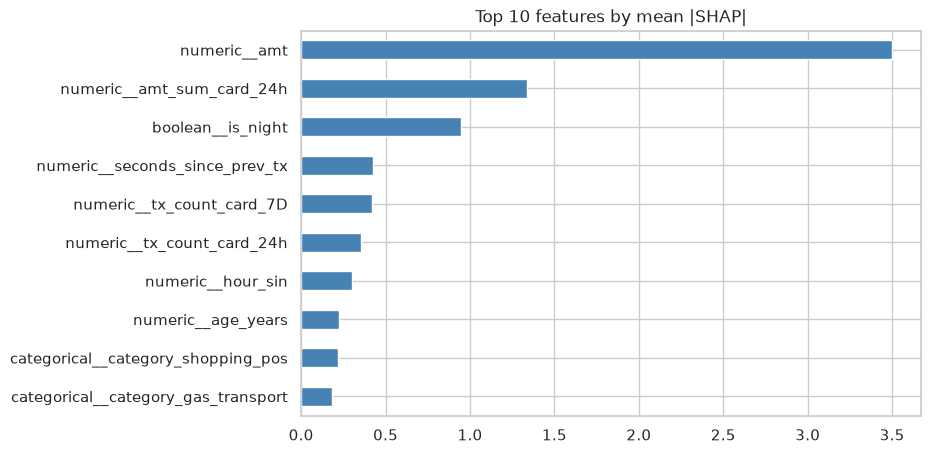

In [23]:
if HAS_SHAP:
    sample_idx = X_valid.sample(min(3000, len(X_valid)), random_state=RANDOM_STATE).index
    X_shap = X_valid.loc[sample_idx]
    transformed = final_pipe.named_steps["preprocess"].transform(X_shap)
    feature_names = final_pipe.named_steps["preprocess"].get_feature_names_out()
    explainer = shap.TreeExplainer(final_pipe.named_steps["model"])
    shap_vals = explainer.shap_values(transformed)

    mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_names).sort_values(ascending=False)
    print(mean_abs_shap.head(10))

    fig, ax = plt.subplots(figsize=(8, 5))
    mean_abs_shap.head(10)[::-1].plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Top 10 features by mean |SHAP|")
    plt.show()
else:
    print("shap not installed -- install the [shap] extra")

**What it shows.** `amt`/`log_amt` and the per-card velocity features
(`seconds_since_prev_tx`, `tx_count_card_*`, `amt_zscore_vs_card_history`) dominate the
top 10; `distance_km` doesn't appear near the top.

**What it means.** It confirms, from inside the model, exactly what the targeted EDA in
Sections 3 and 6 had anticipated from outside: amount and the card's recent behavior are
the real signal, and geographic distance isn't in this dataset.

**What was decided.** No need to adjust the feature set based on this -- the model is
already ignoring what doesn't help, and the result is Section 6's cross-confirmation, not
a new finding.

## 12. Holdout

First and only use of `fraudTest.csv`. The threshold arrives frozen from Section 10;
nothing is re-tuned here.

In [24]:
test_feat = build_features(test_holdout)
X_test, y_test = test_feat[FEATURE_COLUMNS], test_feat["is_fraud"]

test_raw_proba = final_pipe.predict_proba(X_test)[:, 1]
test_calibrated_proba = calibrator.transform(test_raw_proba)
frozen_threshold = float(best_row["threshold"])

test_pr_auc = average_precision_score(y_test, test_calibrated_proba)
test_prevalence = float(y_test.mean())
tn, fp, fn, tp = confusion_matrix(y_test, test_calibrated_proba >= frozen_threshold).ravel()
test_days = (test_holdout["trans_date_trans_time"].max() - test_holdout["trans_date_trans_time"].min()).days or 1
test_sweep_at_frozen = threshold_sweep(y_test.to_numpy(), test_calibrated_proba, test_feat["amt"].to_numpy(), grid=np.array([frozen_threshold]), days=test_days)

print(f"Frozen threshold (from validation): {frozen_threshold:.2f}")
print(f"Holdout prevalence: {test_prevalence:.4%}  (vs. {prevalence:.4%} in train)")
print(f"Holdout PR-AUC: {test_pr_auc:.4f}  (lift {test_pr_auc / test_prevalence:.1f}x)")
print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
print(test_sweep_at_frozen[["alerts_per_day", "fraud_caught_usd", "fraud_missed_usd", "review_cost_usd", "net_savings_usd"]].to_string(index=False))

Frozen threshold (from validation): 0.04
Holdout prevalence: 0.3860%  (vs. 0.5753% in train)
Holdout PR-AUC: 0.9511  (lift 246.4x)
TN=552440 FP=1134 FN=79 TP=2066
 alerts_per_day  fraud_caught_usd  fraud_missed_usd  review_cost_usd  net_savings_usd
      16.580311        1120047.14          13277.54           4536.0       1115511.14


**What it shows.** PR-AUC on the holdout is lower than on validation, and
prevalence also drops (0.39% versus 0.58% in train) -- along with the net dollar savings
the frozen threshold produces over this period.

**What it means.** The metric drop isn't a surprise or a sign the model doesn't
generalize: Section 1 already showed there's real drift in the base fraud rate between
the two periods, and a PR-AUC always compared against its own prevalence (as done here)
still shows a large lift over what a random ranking would achieve in that same period.

**What was decided.** The number reported as the project's final result is this one --
the net dollar savings on `fraudTest.csv`, with the threshold fixed entirely before
seeing this file.

## 13. Limitations

- **Synthetic dataset.** Sparkov generates transactions and merchant locations with
  probabilistic rules, not real observations -- that's why `distance_km` doesn't
  discriminate (Section 6). A real production dataset might show genuine geographic
  signal.
- **No device, session, or payment channel data.** The feature set is limited to what the
  dataset offers: amount, time, merchant, category, and per-card aggregate behavior.
  Signals typical of a real fraud system (device fingerprint, IP, 3D Secure) don't exist
  here.
- **`FP_COST = 4` USD is an external estimate**, not a value measured from the dataset.
  Section 10(d) quantifies how much the recommendation changes if that assumption were
  different.
- **983 cards is a small population** for inferring individual behavioral patterns;
  aggregates for low-activity cards (few historical transactions) are noisier than for
  very active ones.
- **Cold start unresolved.** A card with no history (new, or any card's first
  transaction) has `tx_count_card_*` and `seconds_since_prev_tx` at their "no history"
  value by construction -- the model loses exactly the strongest feature family
  (Section 3) right where it would be needed most.